# GoPay Google Play Review - Data Preprocessing

**Author:** Muhammad Razan Parisya Putra  
**Notebook:** `03 - Preprocessing`

This notebook continues from the review scraping process covered in [2-Gopay-Review-EDA.ipynb](https://colab.research.google.com/drive/1ISGrXpD_I_7GDQQrEpuJN9NpGXTNxeCw?usp=sharing)

---

## Objective

This notebook transforms the raw GoPay review data (from notebook 02 — EDA) into a clean, analysis-ready dataset for sentiment analysis and TF-IDF extraction.

## Preprocessing Pipeline

The preprocessing steps are ordered intentionally — each step depends on the output of the previous one:

| Step | Task | Rationale |
|------|------|-----------|
| 1 | Drop unnecessary columns | Remove metadata not needed for NLP |
| 2 | Handle missing & empty values | Ensure every row has usable text |
| 3 | Remove duplicates | Avoid bias from repeated reviews |
| 4 | Sentiment labeling | Map scores → Positive / Neutral / Negative |
| 5 | Case folding (lowercasing) | Normalize text before any pattern matching |
| 6 | Text cleaning (URLs, emojis, punctuation, numbers) | Remove noise **before** tokenization so tokens are clean |
| 7 | Indonesian slang normalization | Convert informal abbreviations to standard words |
| 8 | Tokenization | Split cleaned text into word tokens |
| 9 | Stopword removal (Indonesian) | Remove common words that don't carry sentiment |
| 10 | Stemming (Indonesian — Sastrawi) | Reduce words to root form |
| 11 | Reconstruct cleaned text | Join tokens back into a single string for TF-IDF |
| 12 | Post-preprocessing validation & comparison | Verify quality and compare before vs after |

## 1. Setup & Installation

In [ ]:
!pip install Sastrawi -q
!pip install emoji -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 16.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import emoji
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_raw.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Dataset loaded: 367,195 rows × 11 columns


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,888c9e2d-b048-4ff5-9dc2-19582ad89693,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54,2.3.0
1,b3a1f5ab-6c0f-489a-9539-79ab670053a8,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN,2.3.0
2,e5045dd9-d082-4158-be52-6d455729cd53,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN,2.3.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367195 entries, 0 to 367194
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              367195 non-null  object
 1   userName              367195 non-null  object
 2   userImage             367195 non-null  object
 3   content               367194 non-null  object
 4   score                 367195 non-null  int64 
 5   thumbsUpCount         367195 non-null  int64 
 6   reviewCreatedVersion  306103 non-null  object
 7   at                    367195 non-null  object
 8   replyContent          61660 non-null   object
 9   repliedAt             61660 non-null   object
 10  appVersion            306103 non-null  object
dtypes: int64(2), object(9)
memory usage: 30.8+ MB


## 3. Drop Unnecessary Columns

For sentiment analysis on review text, we only need the review content, its score, and the timestamp. Columns like `userName`, `userImage`, and `reviewId` are metadata that don't contribute to NLP tasks.

In [ ]:
# Columns to keep for sentiment analysis
cols_to_drop = ['reviewId', 'userName', 'userImage', 'appVersion']

df = df.drop(columns=cols_to_drop)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining columns: {df.columns.tolist()}')
df.head(3)

Dropped 4 columns: ['reviewId', 'userName', 'userImage', 'appVersion']
Remaining columns: ['content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt']


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",1,0,2.3.0,2026-02-28 15:16:28,"Hai Kak Joko, pastikan nomor tujuan sudah bena...",2026-02-28 15:04:54
1,busuk,1,0,2.3.0,2026-02-28 15:14:08,NaN,NaN
2,selalu dapat bonus,5,0,2.3.0,2026-02-28 15:12:17,NaN,NaN


## 4. Handle Missing & Empty Values

In [ ]:
# Check missing values before cleaning
print('Missing values before cleaning:')
df.isnull().sum()

Missing values before cleaning:


,0
content,1
score,0
thumbsUpCount,0
reviewCreatedVersion,61092
at,0
replyContent,305535
repliedAt,305535


In [ ]:
rows_before = len(df)

# Drop rows where 'content' is null or empty/whitespace
df = df.dropna(subset=['content'])
df = df[df['content'].str.strip() != '']

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} rows with missing/empty content')
print(f'Remaining: {rows_after:,} rows')

Removed 1 rows with missing/empty content
Remaining: 367,194 rows


## 5. Remove Duplicate Reviews

Duplicate review text can bias word frequencies and model training. We keep the first occurrence and remove subsequent duplicates.

In [ ]:
rows_before = len(df)

df = df.drop_duplicates(subset=['content'], keep='first')

rows_after = len(df)
print(f'Removed {rows_before - rows_after:,} duplicate reviews')
print(f'Remaining: {rows_after:,} unique reviews')

Removed 148,550 duplicate reviews
Remaining: 218,644 unique reviews


## 6. Convert Data Types

In [ ]:
df['at'] = pd.to_datetime(df['at'])
df['repliedAt'] = pd.to_datetime(df['repliedAt'])

df.dtypes

,0
content,object
score,int64
thumbsUpCount,int64
reviewCreatedVersion,object
at,datetime64[ns]
replyContent,object
repliedAt,datetime64[ns]


## 7. Sentiment Labeling

We create a sentiment label based on the review score. This labeled column will serve as the target variable for sentiment classification.

| Score | Sentiment |
|-------|-----------|
| 1 - 2 | Negative |
| 3     | Neutral  |
| 4 - 5 | Positive |

In [ ]:
def assign_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(assign_sentiment)

df['sentiment'].value_counts()

,count
sentiment,
positive,149295
negative,59804
neutral,9545


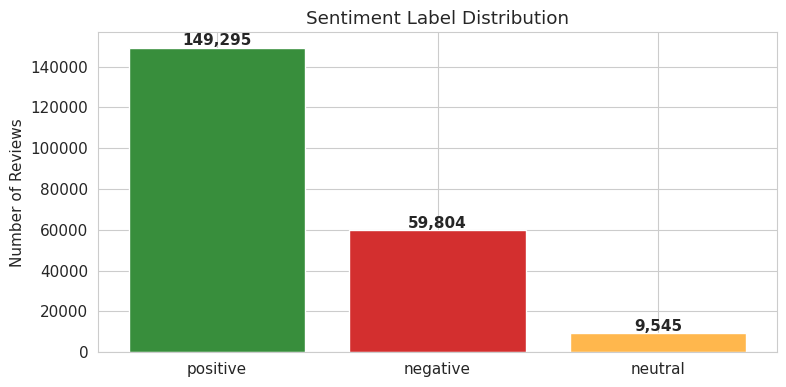


Class proportions:


,proportion
sentiment,
positive,68.28
negative,27.35
neutral,4.37


In [ ]:
# Visualize sentiment distribution
colors_sent = {'positive': '#388e3c', 'neutral': '#ffb74d', 'negative': '#d32f2f'}

fig, ax = plt.subplots(figsize=(8, 4))
sent_counts = df['sentiment'].value_counts()
ax.bar(sent_counts.index, sent_counts.values,
       color=[colors_sent[s] for s in sent_counts.index], edgecolor='white')
ax.set_ylabel('Number of Reviews')
ax.set_title('Sentiment Label Distribution')
for i, (s, c) in enumerate(sent_counts.items()):
    ax.text(i, c + len(df)*0.005, f'{c:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClass proportions:')
(df['sentiment'].value_counts(normalize=True) * 100).round(2)

## 8. Text Preprocessing

This is the core NLP pipeline. Each step is applied sequentially. We store intermediate results in a new column `cleaned_content` to preserve the original `content` column for reference.

> **Important note on language:** GoPay reviews are in **Indonesian (Bahasa Indonesia)**. This means we must use:
> - **Sastrawi** for Indonesian stemming (not Porter/Snowball which are English)
> - **Indonesian stopwords** from Sastrawi (not NLTK's English stopwords)
> - **Indonesian slang dictionary** for normalization (not English contractions)

### 8.1 Case Folding (Lowercasing)

Convert all text to lowercase so that "Bagus", "BAGUS", and "bagus" are treated as the same word. This must happen **before** tokenization and stopword matching.

In [ ]:
df['cleaned_content'] = df['content'].astype(str).str.lower()

# Show before vs after
df[['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,"Baru kali ini pakai gopay kek gini, tadi saya ...","baru kali ini pakai gopay kek gini, tadi saya ..."
1,busuk,busuk
2,selalu dapat bonus,selalu dapat bonus
3,"good, kasih donk promonya","good, kasih donk promonya"
4,terbaik mendukung bwnget,terbaik mendukung bwnget


### 8.2 Text Cleaning

Remove noise elements that don't contribute to sentiment meaning. This is done **before tokenization** so that URLs and special characters don't produce garbage tokens.

What we remove:
- URLs (http/https links)
- Email addresses
- Emojis
- Numbers/digits
- Punctuation & special characters
- Extra whitespace

In [ ]:
def clean_text(text):
    """Remove non-textual noise from a review string."""
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # Remove emojis
    text = emoji.replace_emoji(text, replace='')

    # Remove digits/numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df['cleaned_content'] = df['cleaned_content'].apply(clean_text)

# Show before vs after
df[['content', 'cleaned_content']].sample(5, random_state=42)

,content,cleaned_content
6146,kita sangat puas,kita sangat puas
169599,Aplikasi masih belum sempurna ketika ganti Hp ...,aplikasi masih belum sempurna ketika ganti hp ...
109914,tapi saldoku sisa 1 boleh nambah gak,tapi saldoku sisa boleh nambah gak
367056,Pulsa nya ternyata lebih murah yaa!!,pulsa nya ternyata lebih murah yaa
331589,Lancar gak ribet,lancar gak ribet


### 8.3 Indonesian Slang Normalization

Indonesian informal text is full of abbreviations and slang (e.g., "gak" → "tidak", "bgt" → "banget", "emg" → "memang"). Normalizing these ensures the stemmer can process them correctly and that semantically identical words are unified.

We use a manually curated slang dictionary common in Indonesian app reviews.

In [ ]:
# Indonesian slang dictionary — common abbreviations found in app reviews
slang_dict = {
    'gak': 'tidak', 'ga': 'tidak', 'gk': 'tidak', 'g': 'tidak', 'tdk': 'tidak', 'nggak': 'tidak', 'ngga': 'tidak', 'kagak': 'tidak',
    'tp': 'tapi', 'tpi': 'tapi',
    'utk': 'untuk', 'tuk': 'untuk', 'buat': 'untuk', 'u': 'untuk',
    'yg': 'yang', 'yng': 'yang',
    'dg': 'dengan', 'dgn': 'dengan', 'sm': 'dengan',
    'udh': 'sudah', 'sdh': 'sudah', 'udah': 'sudah', 'uda': 'sudah',
    'blm': 'belum', 'blom': 'belum',
    'lg': 'lagi', 'lgi': 'lagi',
    'bs': 'bisa', 'bsa': 'bisa',
    'klo': 'kalau', 'kl': 'kalau', 'klu': 'kalau', 'kalo': 'kalau',
    'jg': 'juga', 'jga': 'juga',
    'aja': 'saja', 'aj': 'saja',
    'dr': 'dari',
    'krn': 'karena', 'karna': 'karena', 'krna': 'karena',
    'bgt': 'banget', 'bngt': 'banget', 'bngtt': 'banget',
    'bgtt': 'banget', 'bangett': 'banget', 'bener': 'benar',
    'emg': 'memang', 'emang': 'memang',
    'hrs': 'harus',
    'jd': 'jadi', 'jdi': 'jadi',
    'dpt': 'dapat',
    'skrg': 'sekarang', 'skrng': 'sekarang', 'skg': 'sekarang',
    'trs': 'terus', 'trus': 'terus',
    'org': 'orang', 'ornag': 'orang',
    'msh': 'masih',
    'sy': 'saya', 'aku': 'saya', 'gw': 'saya', 'gue': 'saya', 'gua': 'saya', 'w': 'saya',
    'lo': 'kamu', 'lu': 'kamu',
    'gmn': 'bagaimana', 'gimana': 'bagaimana',
    'knp': 'kenapa', 'knapa': 'kenapa',
    'bnr': 'benar',
    'bkn': 'bukan',
    'dmn': 'dimana', 'dmna': 'dimana',
    'gpp': 'tidak apa apa', 'gapapa': 'tidak apa apa',
    'makasih': 'terima kasih', 'makasi': 'terima kasih', 'thx': 'terima kasih', 'thanks': 'terima kasih', 'tq': 'terima kasih',
    'mantap': 'bagus', 'mantab': 'bagus', 'mantapp': 'bagus',
    'top': 'bagus', 'josss': 'bagus', 'jos': 'bagus', 'keren': 'bagus',
    'jelek': 'buruk', 'parah': 'buruk', 'ancur': 'buruk', 'sampah': 'buruk',
    'apk': 'aplikasi', 'app': 'aplikasi',
    'hp': 'handphone',
    'banget': 'sekali',
    'bner': 'benar',
    'ngk': 'tidak', 'engga': 'tidak', 'enggak': 'tidak',
    'dlu': 'dulu', 'dl': 'dulu',
    'pke': 'pakai', 'pake': 'pakai', 'pk': 'pakai',
    'smpe': 'sampai', 'smpai': 'sampai', 'sampe': 'sampai',
    'ntar': 'nanti', 'tar': 'nanti',
    'kmrn': 'kemarin', 'kmarin': 'kemarin',
}

print(f'Slang dictionary size: {len(slang_dict)} entries')

Slang dictionary size: 115 entries


In [ ]:
def normalize_slang(text):
    """Replace Indonesian slang words with their standard form."""
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(normalized)


df['cleaned_content'] = df['cleaned_content'].apply(normalize_slang)

# Show examples where slang was normalized
changed_mask = df['content'].astype(str).str.lower() != df['cleaned_content']
df[changed_mask][['content', 'cleaned_content']].head(5)

,content,cleaned_content
0,"Baru kali ini pakai gopay kek gini, tadi saya ...",baru kali ini pakai gopay kek gini tadi saya b...
3,"good, kasih donk promonya",good kasih donk promonya
5,token nya murah2,token nya murah
6,kalau emang udah tidak ada niat pengadaan top ...,kalau memang sudah tidak ada niat pengadaan ba...
7,GOPAY SOK AKRAB SAMSUNG JELEK,gopay sok akrab samsung buruk


### 8.4 Tokenization

Split the cleaned text into individual word tokens. At this point the text is already lowercase, cleaned, and slang-normalized — so the tokens produced will be high quality.

In [ ]:
df['tokens'] = df['cleaned_content'].apply(word_tokenize)

df[['cleaned_content', 'tokens']].head(5)

,cleaned_content,tokens
0,baru kali ini pakai gopay kek gini tadi saya b...,"[baru, kali, ini, pakai, gopay, kek, gini, tad..."
1,busuk,[busuk]
2,selalu dapat bonus,"[selalu, dapat, bonus]"
3,good kasih donk promonya,"[good, kasih, donk, promonya]"
4,terbaik mendukung bwnget,"[terbaik, mendukung, bwnget]"


In [ ]:
# Token count stats
df['token_count'] = df['tokens'].apply(len)

print(f'Token count statistics:')
df['token_count'].describe().round(1)

Token count statistics:


,token_count
count,218644.0
mean,10.6
std,11.7
min,0.0
25%,4.0
50%,6.0
75%,13.0
max,100.0


### 8.5 Stopword Removal (Indonesian)

Stopwords are high-frequency words that carry little semantic meaning (e.g., "yang", "dan", "di", "ke"). We use Sastrawi's built-in Indonesian stopword list and extend it with additional domain-specific stopwords found during EDA.

In [ ]:
# Load Sastrawi's Indonesian stopwords
stop_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stop_factory.get_stop_words())

# Add custom domain-specific stopwords
custom_stopwords = {
    'gopay', 'gojek', 'aplikasi', 'handphone',
    'nya', 'aja', 'sih', 'dong', 'deh', 'loh', 'nih', 'lah', 'kan', 'kok',
    'ya', 'yah', 'oh', 'ah', 'eh', 'wah',
    'tuh', 'tau', 'mau', 'mulu', 'nih', 'gitu', 'gini',
}

all_stopwords = indonesian_stopwords.union(custom_stopwords)

print(f'Sastrawi stopwords  : {len(indonesian_stopwords)}')
print(f'Custom stopwords    : {len(custom_stopwords)}')
print(f'Total stopwords     : {len(all_stopwords)}')
print(f'\nSample stopwords: {sorted(list(all_stopwords))[:20]}')

Sastrawi stopwords  : 123
Custom stopwords    : 26
Total stopwords     : 147

Sample stopwords: ['ada', 'adalah', 'agak', 'agar', 'ah', 'aja', 'akan', 'amat', 'anda', 'antara', 'anu', 'apakah', 'apalagi', 'aplikasi', 'atau', 'bagaimanapun', 'bagi', 'bahwa', 'begitu', 'belum']


In [ ]:
def remove_stopwords(tokens):
    """Remove Indonesian stopwords from token list."""
    return [t for t in tokens if t not in all_stopwords and len(t) > 1]


df['tokens_no_sw'] = df['tokens'].apply(remove_stopwords)

df[['tokens', 'tokens_no_sw']].head(5)

,tokens,tokens_no_sw
0,"[baru, kali, ini, pakai, gopay, kek, gini, tad...","[baru, kali, pakai, kek, tadi, bagus, up, lewa..."
1,[busuk],[busuk]
2,"[selalu, dapat, bonus]","[selalu, bonus]"
3,"[good, kasih, donk, promonya]","[good, kasih, donk, promonya]"
4,"[terbaik, mendukung, bwnget]","[terbaik, mendukung, bwnget]"


In [ ]:
# Stopword removal impact
total_before = df['tokens'].apply(len).sum()
total_after = df['tokens_no_sw'].apply(len).sum()
total_removed = total_before - total_after

print(f'Total tokens before stopword removal : {total_before:,}')
print(f'Total tokens after stopword removal  : {total_after:,}')
print(f'Tokens removed                       : {total_removed:,} ({total_removed/total_before*100:.1f}%)')

Total tokens before stopword removal : 2,324,725
Total tokens after stopword removal  : 1,511,864
Tokens removed                       : 812,861 (35.0%)


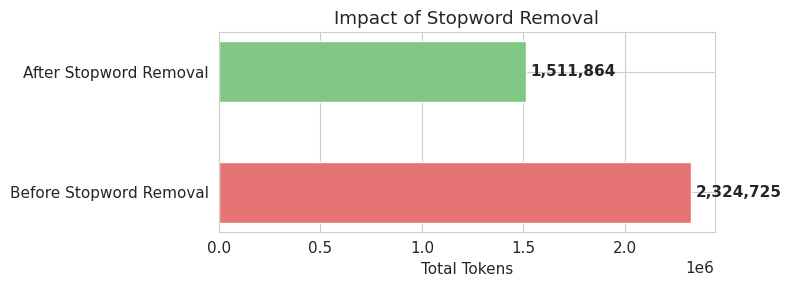

In [ ]:
# Visualize stopword removal impact
fig, ax = plt.subplots(figsize=(8, 3))

categories = ['Before Stopword Removal', 'After Stopword Removal']
values = [total_before, total_after]
bar_colors = ['#e57373', '#81c784']

bars = ax.barh(categories, values, color=bar_colors, edgecolor='white', height=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + total_before*0.01, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontweight='bold')

ax.set_xlabel('Total Tokens')
ax.set_title('Impact of Stopword Removal')
plt.tight_layout()
plt.show()

### 8.6 Stemming (Sastrawi — Indonesian)

Stemming reduces words to their root/base form. For Indonesian, we use **Sastrawi** which understands Indonesian morphology (prefixes like *me-*, *ber-*, *pe-*, suffixes like *-kan*, *-an*, *-i*).

> **Why stemming and NOT lemmatization?**
> - The Relive notebook applied **both** lemmatization and stemming — this is redundant since they serve the same purpose (word normalization). Applying both can actually degrade results.
> - For Indonesian, Sastrawi's stemmer is more appropriate than NLTK's WordNet lemmatizer (which is designed for English).
> - We pick **one** method: Sastrawi stemming.

⚠️ **Note:** Sastrawi stemming on 300K+ reviews takes time (~10-20 minutes). Be patient.

In [ ]:
# Initialize the Sastrawi stemmer
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()


def stem_tokens(tokens):
    """Apply Indonesian stemming to each token."""
    return [stemmer.stem(token) for token in tokens]


# Apply stemming — this will take some time
print('Stemming in progress... (this may take 10-20 minutes on 300K+ reviews)')
df['tokens_stemmed'] = df['tokens_no_sw'].apply(stem_tokens)
print('Stemming complete!')

df[['tokens_no_sw', 'tokens_stemmed']].head(5)

Stemming in progress... (this may take 10-20 minutes on 300K+ reviews)


In [ ]:
# Show stemming examples
print('Stemming examples:')
sample_words = ['pembayaran', 'melakukan', 'penggunaan', 'membantu', 'mengirim', 'perbaikan', 'mengecewakan', 'bermasalah']
for word in sample_words:
    print(f'  {word:20s} → {stemmer.stem(word)}')

### 8.7 Reconstruct Cleaned Text

After all token-level processing, we join the tokens back into a single string. This `final_text` column will be used for TF-IDF and sentiment analysis.

In [ ]:
df['final_text'] = df['tokens_stemmed'].apply(lambda tokens: ' '.join(tokens))

df[['content', 'final_text']].head(10)

In [ ]:
# Remove rows where final_text is empty after all preprocessing
rows_before = len(df)
df = df[df['final_text'].str.strip() != '']
rows_after = len(df)

print(f'Removed {rows_before - rows_after:,} rows with empty text after preprocessing')
print(f'Final dataset size: {rows_after:,} reviews')

## 9. Post-Preprocessing Validation

We now compare the data before and after preprocessing to verify the pipeline worked correctly and to understand its impact.

In [ ]:
# 9.1 — Side-by-side comparison: Original vs Final
comparison = df[['content', 'final_text', 'score', 'sentiment']].sample(10, random_state=42)
comparison

In [ ]:
# 9.2 — Word count comparison: before vs after
df['original_word_count'] = df['content'].astype(str).str.split().str.len()
df['final_word_count'] = df['final_text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['original_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#e57373', label='Original')
axes[0].hist(df['final_word_count'].clip(upper=50), bins=50, alpha=0.7,
             color='#81c784', label='After Preprocessing')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution: Before vs After Preprocessing')
axes[0].legend()

# Average word count by sentiment
sent_order = ['negative', 'neutral', 'positive']
avg_wc = df.groupby('sentiment')['final_word_count'].mean().reindex(sent_order)
bar_colors = [colors_sent[s] for s in sent_order]
axes[1].bar(sent_order, avg_wc.values, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Average Word Count')
axes[1].set_title('Average Word Count per Sentiment (After Preprocessing)')
for i, v in enumerate(avg_wc.values):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 9.3 — Top words AFTER preprocessing (compare with EDA's raw word frequency)
all_final_words = ' '.join(df['final_text']).split()
final_word_freq = Counter(all_final_words)

top_30_final = final_word_freq.most_common(30)
words_f, counts_f = zip(*top_30_final)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(range(len(words_f)), counts_f, color='#81c784', edgecolor='white')
ax.set_yticks(range(len(words_f)))
ax.set_yticklabels(words_f)
ax.invert_yaxis()
ax.set_xlabel('Frequency')
ax.set_title('Top 30 Most Frequent Words (After Preprocessing)')
plt.tight_layout()
plt.show()

In [ ]:
# 9.4 — Top words by sentiment group (after preprocessing)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sent_groups = {
    'Negative': df[df['sentiment'] == 'negative'],
    'Neutral': df[df['sentiment'] == 'neutral'],
    'Positive': df[df['sentiment'] == 'positive']
}
group_colors = ['#d32f2f', '#ffb74d', '#388e3c']

for ax, (label, grp_df), color in zip(axes, sent_groups.items(), group_colors):
    grp_words = Counter(' '.join(grp_df['final_text']).split()).most_common(15)
    w, c = zip(*grp_words)
    ax.barh(range(len(w)), c, color=color, alpha=0.8)
    ax.set_yticks(range(len(w)))
    ax.set_yticklabels(w)
    ax.invert_yaxis()
    ax.set_title(f'{label}')
    ax.set_xlabel('Frequency')

plt.suptitle('Top 15 Words by Sentiment (After Preprocessing)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Final Data Overview & Column Selection

In [ ]:
# 10.1 — Final dataframe overview
df.info()

In [ ]:
df.head(5)

In [ ]:
# 10.2 — Select and save only the columns needed for sentiment analysis
cols_to_save = ['content', 'score', 'at', 'thumbsUpCount', 'replyContent',
                'sentiment', 'final_text', 'tokens_stemmed']

df_clean = df[cols_to_save].copy()

print(f'Columns selected for export: {cols_to_save}')
print(f'Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
df_clean.head(5)

## 11. Preprocessing Summary

| Metric | Value |
|--------|-------|
| Original rows | (fill in) |
| Rows after removing missing/empty | (fill in) |
| Rows after removing duplicates | (fill in) |
| Final rows after preprocessing | (fill in) |
| Stopwords removed | (fill in)% of tokens |
| Unique words (post-preprocessing) | (fill in) |

### Pipeline Applied

1. ✅ Dropped 4 irrelevant columns (`reviewId`, `userName`, `userImage`, `appVersion`)
2. ✅ Removed missing and empty content rows
3. ✅ Removed duplicate review text
4. ✅ Labeled sentiment from score (Negative / Neutral / Positive)
5. ✅ Case folding (lowercasing)
6. ✅ Text cleaning (URLs, emails, emojis, numbers, punctuation)
7. ✅ Indonesian slang normalization (70+ entries)
8. ✅ Tokenization
9. ✅ Indonesian stopword removal (Sastrawi + custom)
10. ✅ Indonesian stemming (Sastrawi)
11. ✅ Reconstructed final text for TF-IDF

### Improvements Over Previous Semester

| Aspect | Previous (Relive) | Current (GoPay) |
|--------|------------------|------------------|
| Language tools | English (NLTK, Porter Stemmer) | Indonesian (Sastrawi) |
| Stemming + Lemmatization | Both applied (redundant) | Only stemming (Sastrawi) |
| Pipeline order | Tokenize → lowercase → ... → punctuation last | Lowercase → clean → tokenize → ... (correct) |
| Slang normalization | English contractions only | Indonesian slang dictionary (70+ entries) |
| Spelling correction | English SymSpell (wrong language) | Replaced with slang normalization (appropriate) |
| Text cleaning | Punctuation only | URLs, emails, emojis, numbers, punctuation |
| Duplicate handling | Not done | Removed duplicate reviews |

## 12. Save Preprocessed Data

In [ ]:
# Save to CSV
output_path = '/content/drive/MyDrive/Tugas 1/Dataset/gopay_reviews_clean.csv'
df_clean.to_csv(output_path, index=False)

print(f'Preprocessed data saved to: {output_path}')
print(f'Shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')